In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ejercicio 1a)
def bernstein3(t):
    matriz = []

    for valor in t:
        matriz.append([(1-valor)**3, 3*(1-valor)**2*valor, 3*(1-valor)*valor**2, valor**3])

    return np.array(matriz)

# Ejercicio 1b)

valores_de_t = np.linspace(0, 1, 100)

matriz = bernstein3(valores_de_t)

plt.plot(valores_de_t, matriz[:, 0], label="b0(t)")
plt.plot(valores_de_t, matriz[:, 1], label="b1(t)")
plt.plot(valores_de_t, matriz[:, 3], label="b3(t)")
plt.plot(valores_de_t, matriz[:, 2], label="b2(t)")

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

Esto se puede verificar muy facilmente viendo que que al sumar todos los polinomios de Bernstein, las "t" desaparecen:
Computacionalmente puede haber pequeños errores decimales, como ocurrió aca:

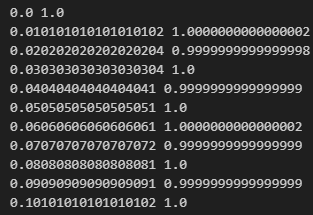

Así que usamos una tolerancia para ver si ocurre o no:

In [4]:
def suma_bernstein(t):
    b0 = (1-t)**3
    b1 = 3*(1-t)**2*t
    b2 = 3*(1-t)*t**2
    b3 = t**3

    return b0 + b1 + b2 + b3

ocurre = True
for t in valores_de_t:
    suma = suma_bernstein(t)
    if abs(suma - 1) > 0.0000001:
        ocurre = False

if ocurre:
    print("Efectivamente la suma siempre da 1 sin importar el valor de t")

NameError: name 'valores_de_t' is not defined

Los polinomios de Bernstein funcionan como pesos sobre los puntos de control.
Como, para todo t entre 0 y 1, su suma es 1, cada punto de la curva de Bézier es una combinación lineal convexa de los puntos de control. Esto garantiza que la curva queda dentro del poligono convexo determinado por esos puntos.
Además, cuando t = 0, el único peso distinto de cero es el de P0, por lo que la curva comienza en P0. Cuando t = 1, el único peso distinto de cero es el de P_3, por lo que la curva termina en P_3.

In [5]:
# Ejercicio 2a)

valores_de_t = np.linspace(0, 1, 100)
A = bernstein3(valores_de_t)

# Ejercicio 2b)

P0 = [0,0]
P1 = [1,3]
P2 = [4,3]
P3 = [5,0]

P = np.array([P0, P1, P2, P3])

# Ejercicio 2c)
C = A @ P

# Ejercicio 2d)

plt.plot(C[:,0], C[:,1], label="Curva Bézier") # dibuja una linea que une todos los puntos calculados

plt.scatter(*P0)
plt.scatter(*P1)
plt.scatter(*P2)
plt.scatter(*P3)

plt.plot(P[:,0], P[:,1], '--', label="Poligonal")

plt.legend()
plt.show()


NameError: name 'bernstein3' is not defined

Dado m = 100 (valores de t entre 0 y 1):
- Por un lado la matriz A tendra dimensiones m x 4. 
- Por otro lado, P tiene dimensiones 4 x 2.
- Por ultimo, C tiene dimensiones m x 2.

La matriz A contiene 100 filas porque evaluamos la curva en 100 valores de t y 4 columnas porque hay 4 funciones de bernstein: b0(t), b1(t), b2(t) y b3(t).

P es la matriz que contiene los puntos de control. Tiene 4 filas porque hay 4 puntos de control y 2 columnas porque cada punto tiene 2 coordenadas.

C es la matriz de puntos de la curva. Tiene 100 filas porque contiene los 100 puntos calculados de la curva y 2 columnas porque cada puntos tiene 2 coordenadas.


In [6]:
A.shape
P.shape
C.shape

NameError: name 'A' is not defined

In [7]:
import sys
!{sys.executable} -m pip uninstall -y matplotlib
!{sys.executable} -m pip install matplotlib --force-reinstall

  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     --- ------------------------------------ 10.2/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 1.2 MB/s eta 0:00:00
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)


ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python312\\Scripts\\f2py.exe' -> 'c:\\Python312\\Scripts\\f2py.exe.deleteme'


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
